In [8]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


In [9]:
"""
Task: Given runs, noOfBalls, fours and sixes

Calculate: SR, ballPerBoundary, boundarPercentage

"""

'\nTask: Given runs, noOfBalls, fours and sixes\n\nCalculate: SR, ballPerBoundary, boundarPercentage\n\n'

In [10]:
class BatsmanStats(TypedDict):
    runs: int
    noOfBalls: int
    fours: int
    sixes: int
    sr: float
    ballPerBoundary: float
    boundaryPercentage: float
    summary: str

In [ ]:
def calculate_sr(stats: BatsmanStats):
    sr = (stats['runs'] / stats['noOfBalls']) * 100
    return {'sr': sr} # partial update


def calculate_ball_per_boundary(stats: BatsmanStats):
    total_boundaries = stats['fours'] + stats['sixes']
    if total_boundaries > 0:
        ball_per_boundary = stats['noOfBalls'] / total_boundaries
    else:
        ball_per_boundary = float('inf')  # No boundaries hit
    return {'ballPerBoundary': ball_per_boundary} # partial update


def calculate_boundary_percentage(stats: BatsmanStats):
    if stats['runs'] > 0:
        boundary_percentage = ((stats['fours'] * 4 + stats['sixes'] * 6) / stats['runs']) * 100
    else:
        boundary_percentage = 0.0  # No runs scored
    return {'boundaryPercentage': boundary_percentage} # partial update 


def summary(stats: BatsmanStats) -> BatsmanStats:
    text = (
        f"strike rate: {stats['sr']}, "
        f"ball per boundary: {stats['ballPerBoundary']}, "
        f"boundary percentage: {stats['boundaryPercentage']}"
    )
    return {'summary': text} # partial update




In [16]:
stats_graph = StateGraph(BatsmanStats)

stats_graph.add_node('calculate_sr', calculate_sr)
stats_graph.add_node('calculate_ball_per_boundary', calculate_ball_per_boundary)
stats_graph.add_node('calculate_boundary_percentage', calculate_boundary_percentage)
stats_graph.add_node('summary', summary)


stats_graph.add_edge(START, 'calculate_ball_per_boundary')
stats_graph.add_edge(START, 'calculate_boundary_percentage')
stats_graph.add_edge(START, 'calculate_sr')


stats_graph.add_edge('calculate_sr', 'summary')
stats_graph.add_edge('calculate_ball_per_boundary', 'summary')
stats_graph.add_edge('calculate_boundary_percentage', 'summary')

stats_graph.add_edge('summary', END)

stats_workflow = stats_graph.compile()




In [17]:
stats_workflow.invoke({
    "runs": 100,
    "noOfBalls": 60,
    "fours": 10,
    "sixes": 5
})

{'runs': 100,
 'noOfBalls': 60,
 'fours': 10,
 'sixes': 5,
 'sr': 166.66666666666669,
 'ballPerBoundary': 4.0,
 'boundaryPercentage': 70.0,
 'summary': 'strike rate: 166.66666666666669, ball per boundary: 4.0, boundary percentage: 70.0'}

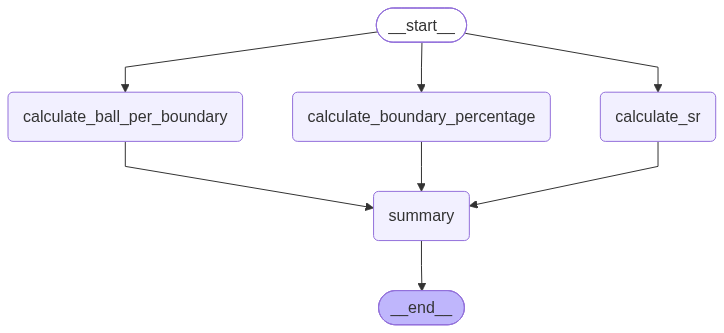

In [18]:
stats_workflow